# Notebook for constructing age models for the Mamainse Point Volcanics

In [1]:
using Pkg
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

plot_posterior_paths (generic function with 1 method)

## Maminase Point Volcanics

- The bottom of the section (lower R1 pole) is > ca. 1107 Ma, let's set it to be 1110 Ma which is thought to be the beginnin of the Midcontinent Rift
- The Flour Bay Tuff is dated to be 1100.36 $\pm$ 0.25 Ma which can be used as one constraint at strat height 2000
- The top of the section is of normal polarity with no radiometric constraints, let's set it to be 1090 $\pm$ 4 Ma

In [2]:
Mamainse_Name = ("Base of Mamainse", "Agate Point rhyolite flow", "Top of Osler") # Et cetera
Mamainse_Age           = [ 1110, 1100.36, 1090] # Measured ages
Mamainse_Age_sigma     = [ 2/2,     0.25/2, 4/2] # Measured 1-σ uncertainties
Mamainse_Height        = [ 0.0,     2000,  4100] # Depths below surface should be negative
Mamainse_Age_Sidedness = [0, 0, 0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

Mamainse_Path = "../code_output/age_models/Mamainse_Point_Volcanic_Group" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
Mamainse_section = make_ChronAgeData(Mamainse_Name, Mamainse_Age, Mamainse_Age_sigma, Mamainse_Height, Mamainse_Age_Sidedness, Mamainse_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{3}(("Base of Mamainse", "Agate Point rhyolite flow", "Top of Osler"), [0.0, 2000.0, 4100.0], [0.01, 0.01, 0.01], [1110.0, 1100.36, 1090.0], [1.0, 0.125, 2.0], [NaN, NaN, NaN], [NaN, NaN, NaN], [NaN, NaN, NaN], [NaN, NaN, NaN], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [#undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer), [NaN NaN NaN; NaN NaN NaN; … ; NaN NaN NaN; NaN NaN NaN], "../code_output/age_models/Mamainse_Point_Volcanic_Group", 2, "Ma", "m", :cdf)

In [3]:
Mamainse_age_model_config, Mamainse_age_model_mdl, Mamainse_age_model_agedist, Mamainse_age_model_lldist = run_age_model(Mamainse_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:28
┌ Info: Burn-in: 575000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 575000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 575000, 1000, 575, 0.2), StratAgeModel([0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0  …  4010.0, 4020.0, 4030.0, 4040.0, 4050.0, 4060.0, 4070.0, 4080.0, 4090.0, 4100.0], [1110.0682509672768, 1109.999643229857, 1109.9550113285047, 1109.9027609428256, 1109.8424635863616, 1109.7927305057958, 1109.7508050904373, 1109.691766412746, 1109.646889877526, 1109.6002280479483  …  1090.3895420787248, 1090.3350368489093, 1090.2896435515074, 1090.239099730534, 1090.1892624396453, 1090.132639827137, 1090.0932363851073, 1090.0401452380052, 1089.9937701713764, 1089.938211899225], [0.9025683544331482, 0.9522845807635469, 0.9837347664391374, 1.002910735698065, 1.0453087530768856, 1.0650753417893681, 1.0802401428951556, 1.1218366596174938, 1.15505281453205, 1.185501892148782  …  1.6918130188542484, 1.6618652204347562, 1.6366338067673776, 1.6160294831827822, 1.5718960190996307, 1.5406766169691797, 1.524018397761774, 1.4955431434887008, 1.475890904994809, 1.4643

### posterior summary age model

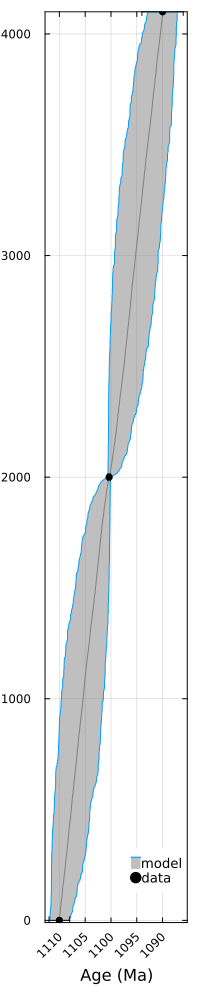

In [4]:
Mamainse_age_model = plot_age_model(Mamainse_section, Mamainse_age_model_mdl, save_figure=false)
plot!(ylim=(-10, 4100))
# savefig(Mamainse_age_model, Mamainse_section.Path*"_AgeDepthModel.pdf")
display(Mamainse_age_model)

### example posterior accumulation models

  0.005480 seconds (19.00 k allocations: 13.901 MiB)


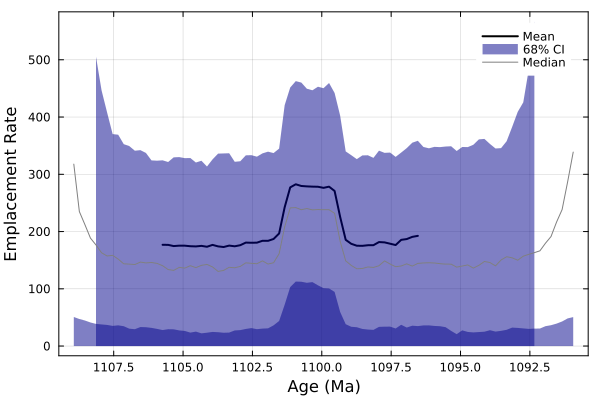

In [5]:
plot_accumulation_model(Mamainse_section, Mamainse_age_model_config, Mamainse_age_model_mdl, Mamainse_age_model_agedist, save_figure=false)

### example posterior age models

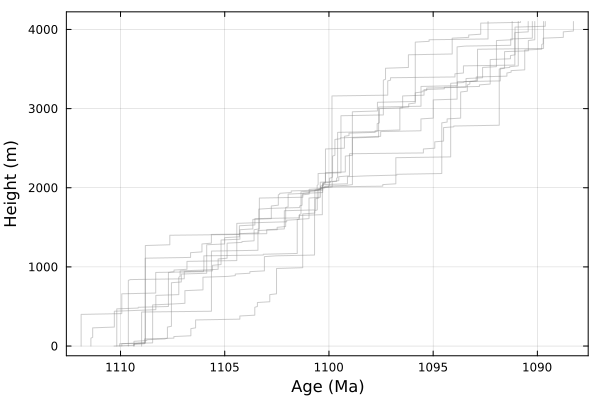

In [6]:
plot_posterior_paths(Mamainse_section, Mamainse_age_model_agedist, Mamainse_age_model_mdl)

## save the age models to a file

In [7]:
# use the mdl.height as index, agedist as the data
Mamainse_age_models_df = DataFrame(hcat(Mamainse_age_model_mdl.Height, Mamainse_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(Mamainse_age_models_df, Dict(:x1 => "height"))
Mamainse_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1108.69,1112.31,1110.17,1110.24,1109.66,1110.87,1109.9,1110.88,1110.99,1109.3,1111.29,1111.1,1110.65,1109.92,1108.99,1110.27,1110.8,1110.18,1108.84,1109.61,1111.07,1109.32,1108.11,1109.42,1110.67,1110.7,1110.36,1111.14,1109.7,1110.93,1109.88,1110.61,1111.97,1108.73,1109.4,1110.56,1110.9,1109.68,1110.17,1111.0,1107.22,1110.45,1110.43,1112.45,1107.8,1109.78,1109.34,1108.94,1108.45,1110.89,1108.82,1110.91,1109.7,1108.59,1110.97,1110.66,1109.37,1110.9,1109.6,1109.56,1107.41,1109.98,1111.26,1107.88,1110.79,1110.76,1110.93,1111.34,1110.04,1110.03,1110.63,1108.3,1109.6,1110.12,1110.02,1109.64,1107.9,1108.71,1109.94,1111.04,1109.54,1111.04,1109.3,1110.68,1109.82,1108.49,1110.29,1110.22,1110.01,1108.79,1110.54,1110.64,1109.9,1110.87,1111.14,1110.78,1109.44,1109.42,1109.88,⋯
2,10.0,1108.69,1112.31,1110.17,1110.24,1109.3,1110.87,1109.9,1110.88,1110.99,1109.3,1111.29,1111.1,1110.65,1109.92,1108.99,1110.27,1110.8,1110.18,1108.84,1109.61,1111.07,1109.32,1108.11,1108.6,1110.67,1110.7,1110.36,1111.14,1109.7,1110.93,1109.88,1110.61,1111.97,1108.73,1109.4,1110.56,1110.9,1109.68,1108.97,1111.0,1107.22,1110.45,1110.43,1112.45,1107.8,1109.78,1109.34,1107.86,1108.45,1110.89,1108.82,1110.91,1109.7,1108.59,1110.28,1109.03,1109.37,1110.9,1109.6,1109.56,1107.41,1109.46,1111.26,1107.88,1110.79,1110.76,1110.93,1111.34,1110.04,1110.0,1110.63,1108.3,1109.6,1110.12,1110.02,1109.64,1107.9,1108.71,1109.94,1111.04,1109.54,1111.04,1109.3,1110.68,1109.82,1108.49,1110.29,1110.22,1106.67,1108.79,1110.54,1110.64,1109.9,1110.87,1111.14,1110.78,1109.44,1108.27,1109.88,⋯
3,20.0,1108.69,1112.31,1110.17,1110.24,1109.3,1110.26,1109.9,1110.88,1110.99,1109.3,1111.29,1111.1,1110.65,1109.92,1108.99,1110.27,1110.8,1110.18,1108.84,1109.61,1111.07,1109.32,1108.09,1108.6,1110.67,1110.7,1110.36,1111.14,1109.7,1110.93,1109.88,1110.61,1111.97,1108.73,1109.4,1109.38,1110.9,1109.68,1108.97,1111.0,1107.22,1110.45,1110.43,1112.45,1107.8,1109.78,1109.34,1107.86,1108.45,1110.38,1108.82,1110.91,1109.7,1108.59,1110.28,1109.03,1109.37,1110.9,1109.6,1109.56,1107.41,1109.46,1110.46,1107.88,1110.79,1110.76,1110.93,1111.34,1110.04,1109.93,1110.63,1108.3,1109.6,1110.12,1110.02,1109.64,1107.9,1108.71,1109.94,1111.04,1109.54,1111.04,1109.3,1110.68,1109.82,1108.49,1110.29,1110.22,1106.67,1108.79,1110.54,1110.64,1109.9,1110.87,1111.14,1110.78,1109.44,1108.27,1109.88,⋯
4,30.0,1108.69,1112.31,1110.17,1110.24,1109.3,1110.26,1109.9,1110.88,1110.99,1109.3,1111.29,1111.1,1110.65,1109.92,1107.23,1110.27,1110.8,1110.18,1108.84,1109.61,1111.07,1109.32,1107.89,1108.6,1110.67,1110.7,1110.36,1111.14,1109.7,1110.93,1109.88,1110.61,1111.97,1108.73,1109.4,1109.38,1110.9,1109.68,1108.42,1111.0,1107.22,1110.45,1110.07,1112.45,1107.8,1109.78,1109.34,1107.86,1108.28,1110.38,1108.04,1110.91,1109.7,1108.59,1110.28,1109.03,1109.37,11

In [8]:
# write the DataFrame to a csv file
CSV.write(Mamainse_section.Path*"_posterior_ages.csv", Mamainse_age_models_df)

"../code_output/age_models/Mamainse_Point_Volcanic_Group_posterior_ages.csv"